## **Summary**
This notebook demonstrates a workflow for inferring transcription factor activities from RNA-seq data:
1. RNA-seq data loading and preprocessing.
2. Loading prior knowledge about TF–target interactions.
3. Inferring TF activity using decoupleR.
4. Ranking and visualizing TF activities per cell type.
5. Estimating and visualizing the reliability of inferred TF activity scores.

## **Importing required packages**

In [2]:
import decoupler as dc
import scanpy as sc
import tfactprofiler as tfp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=80,facecolor="white",frameon=False)

/var/folders/jc/_3r0jj3n5sn_cb44k7r6c1hm0000gn/T/ipykernel_99150/3734722728.py:8: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80,facecolor="white",frameon=False)


## **Loading single-cell RNA-seq data**.   
Here we use PBMC dataset as an example.  
You can use your own dataset by loading it with scanpy.

AnnData object with n_obs × n_vars = 2638 × 3000
    obs: 'n_genes', 'percent_mito', 'n_counts', 'celltype', 'leiden'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    obsp: 'distances', 'connectivities'


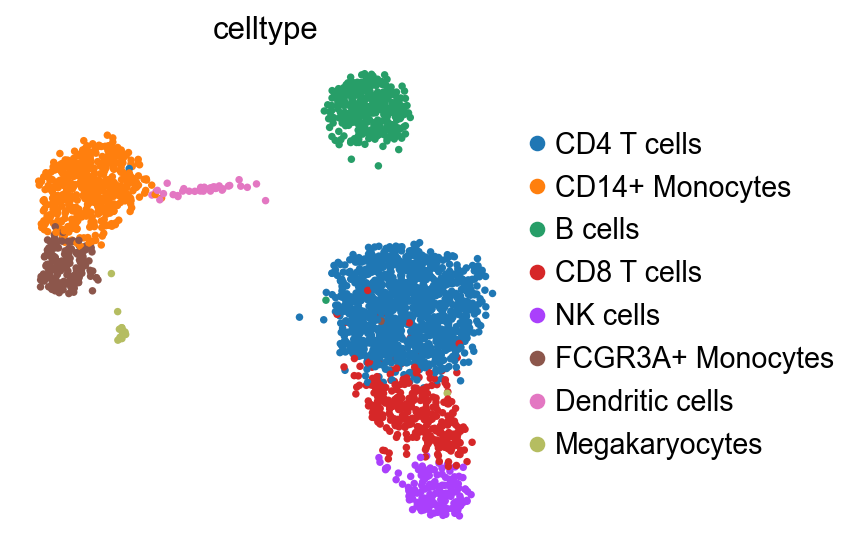

In [3]:
adata = dc.ds.pbmc3k()
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="cell_ranger")
adata=adata[:, adata.var['highly_variable']].copy()
print(adata)
sc.pl.umap(adata=adata,color="celltype")

## **Loading prior knowledge (transcription factor–target mRNA interactions)**
This repository includes curated priors that encode transcription factor–to–mRNA relationships. The file, TFactprofiler_all.csv, aggregates interactions learned from a diverse collection of organs and cell types. This makes it the recommended default when broad generalizability across tissues is desired. For studies that require tissue- or cell-type-specificity, the tfact_organ directory provides models that were trained separately using data from each organ or cell type. You can select the file named after the organ of interest to bias the inference toward that context. All files consist of a transcription factor (source), target, and an interaction weight. One practical approach is to start with the TFactprofiler_all.csv file to establish a baseline. Then, if needed, repeat the analysis with the organ-specific file to assess tissue-specific effects or prioritize regulatory edges enriched in the focal context.

In [4]:
tfactprofiler_data=pd.read_csv("TFactprofiler_all.csv")
tfactprofiler_data

,source,target,weight
0,ADNP,BECN1,0.015420
1,ADNP2,HBB,0.002102
2,AEBP1,TFAP2A,-0.016116
3,AFP,ACAP1,0.013770
4,AFP,ACTBL2,0.032874
...,...,...,...
2606171,ZSCAN10,ZSCAN10,0.379152
2606172,SIX2,SIX2,0.379152
2606173,MYOCD,MYOCD,0.379152
2606174,SIRT1,SIRT1,0.379152


## **Inferring TF activity with the ULM method**. 
Details of the method can be found in the decoupleR documentation.  
https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_sc.html

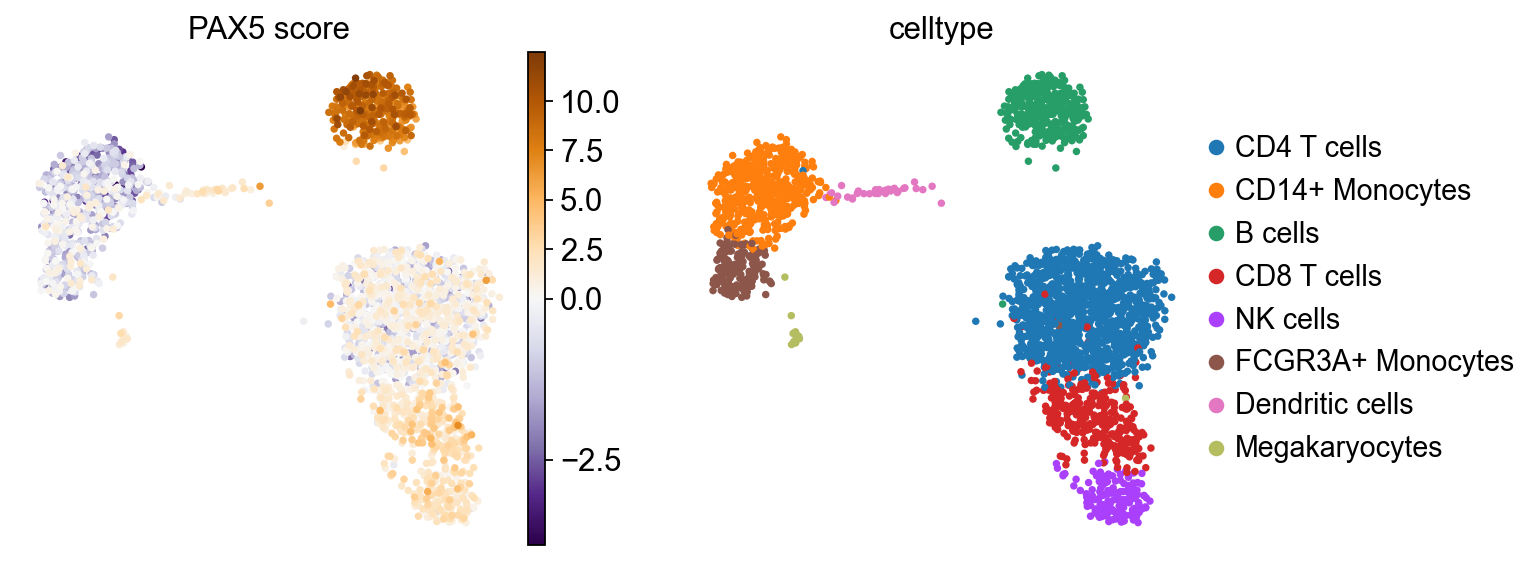

In [5]:
dc.mt.ulm(data=adata, net=tfactprofiler_data)
score = dc.pp.get_obsm(adata=adata, key="score_ulm")

tf = "PAX5"
sc.pl.umap(score, color=[tf, "celltype"], cmap="PuOr_r", vcenter=0, title=[f"{tf} score", "celltype"])
df = dc.tl.rankby_group(adata=score, groupby="celltype", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
n_markers = 3
source_markers = (df.groupby("group").head(n_markers).drop_duplicates("name").groupby("group")["name"].apply(lambda x: list(x)).to_dict())
#sc.pl.matrixplot(adata=score,var_names=source_markers,groupby="celltype",dendrogram=True,standard_scale="var",colorbar_title="Z-scaled scores",cmap="PuOr_r")

## **Estimating reliability of inferred TF activity**.  
The reliability of the inferred TF activity scores can be estimated using tfactprofiler's estimate_reliability function.  
Higher MSE values indicate lower reliability.

[prior] #TFs in W (present): 169
[prior] #targets in W (present +HVG): 2454

[cluster 1/8] CD4 T cells
  cells: 1144

[cluster 2/8] B cells
  cells: 342

[cluster 3/8] CD14+ Monocytes
  cells: 480

[cluster 4/8] NK cells
  cells: 154

[cluster 5/8] CD8 T cells
  cells: 316

[cluster 6/8] FCGR3A+ Monocytes
  cells: 150

[cluster 7/8] Dendritic cells
  cells: 37

[cluster 8/8] Megakaryocytes
  cells: 15


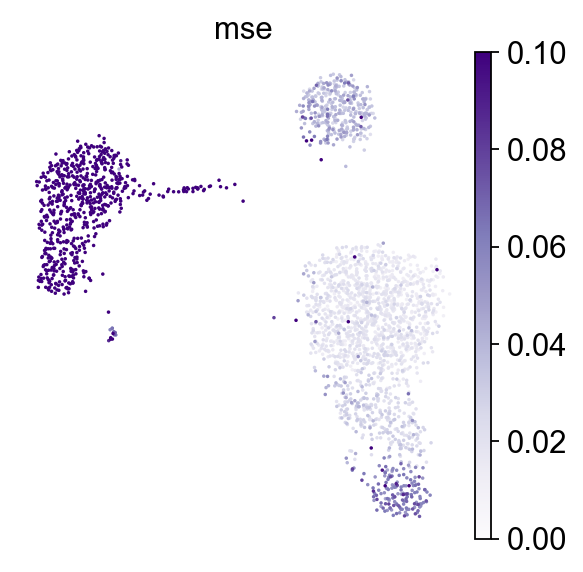

/var/folders/jc/_3r0jj3n5sn_cb44k7r6c1hm0000gn/T/ipykernel_99150/3841382530.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


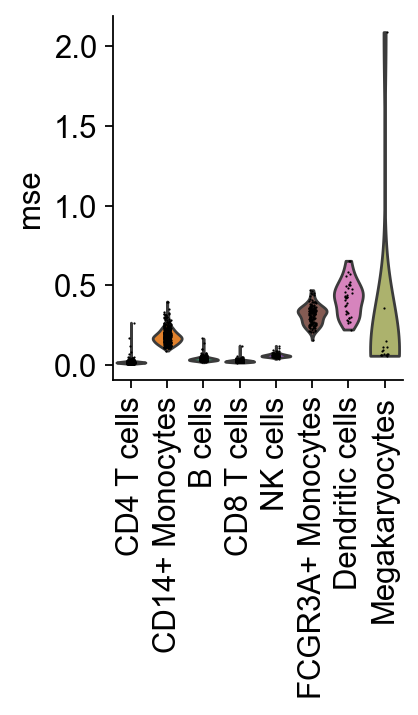

In [6]:
adata=tfp.estimate_reliability(adata,tfactprofiler_data,cluster_key='celltype')
sc.pl.umap(adata, color="mse", color_map='Purples',na_color='lightgray',
           show=True,s=10, vmin=0, vmax=0.1)

ax =sc.pl.violin(adata, "mse", groupby='celltype', rotation=90, show=False)
ax.tick_params(axis='x', rotation=90) 
sns.despine(ax=ax)                 
ax.grid(False)                      
fig = ax.get_figure()
fig.set_size_inches(3,3)
fig.tight_layout()
plt.show()